# Deleting messages permanently from the state
- When we summarize the past conversation, we store the summarized version in the state by deleting the past conversations/messages
- To delete messages `RemoveMessage` from langchain is used

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage

/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Defining the functions
- 1 node to invoke the model to answer the question
- Another node to invoke the delete the old conversations from the state
- In delete_old_messages node 
    - If the message of messages is greater than or equal to 5 then we remove all those messages
    - While using RemoveMessage we need to provide the id of the message that has to be removed
    - Note to return {"messages" : [ RemoveMessage(id=message.id) ]}
    - If the list is not used then it will not work

In [3]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    messages = state["messages"]
    print(f"No of messages before cleanup: {len(messages)}")
    if len(messages) >= 5:
        return {"messages": [RemoveMessage(id = message.id) for message in messages]}

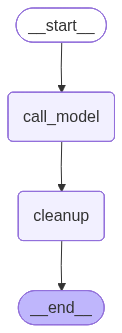

In [4]:
graph = StateGraph(MessagesState)

graph.add_node("call_model", call_model)
graph.add_node("cleanup", delete_old_messages)

graph.add_edge(START, "call_model")
graph.add_edge("call_model", "cleanup")
graph.add_edge("cleanup", END)


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

# Conversation1

In [5]:
from langchain.messages import HumanMessage


config = {"configurable": {"thread_id":"1"}}

workflow.invoke({"messages": HumanMessage(content = "Hi, my name is John")}, config)


No of messages before cleanup: 2


{'messages': [HumanMessage(content='Hi, my name is John', additional_kwargs={}, response_metadata={}, id='21bf9b3a-054a-49c5-8e82-024342369f20'),
  AIMessage(content='<think>\nOkay, the user introduced himself as John and said hello. I need to respond politely. First, I should greet him back warmly. Maybe say "Hello John!" or "Hi John!" to be friendly. Then, offer assistance. Since I don\'t know what he needs help with yet, I should keep it open-ended. Maybe ask "How can I assist you today?" or "What can I help you with?" to encourage him to explain his needs. I should keep the tone positive and approachable, making sure he feels comfortable to ask questions or share his concerns. Also, check for any typos or errors in the response. Keep it concise and welcoming.\n</think>\n\nHello, John! Nice to meet you. How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 14, 'total_tokens': 172, 'completion_time': 0.3408

# Conversation2

In [6]:
workflow.invoke({"messages": HumanMessage(content = "Can you explain langGraph")}, config)


No of messages before cleanup: 4


{'messages': [HumanMessage(content='Hi, my name is John', additional_kwargs={}, response_metadata={}, id='21bf9b3a-054a-49c5-8e82-024342369f20'),
  AIMessage(content='<think>\nOkay, the user introduced himself as John and said hello. I need to respond politely. First, I should greet him back warmly. Maybe say "Hello John!" or "Hi John!" to be friendly. Then, offer assistance. Since I don\'t know what he needs help with yet, I should keep it open-ended. Maybe ask "How can I assist you today?" or "What can I help you with?" to encourage him to explain his needs. I should keep the tone positive and approachable, making sure he feels comfortable to ask questions or share his concerns. Also, check for any typos or errors in the response. Keep it concise and welcoming.\n</think>\n\nHello, John! Nice to meet you. How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 14, 'total_tokens': 172, 'completion_time': 0.3408

- Now the no of messages in the state is 4
- 2 due to the previous question and answer and 2 more for the current question and answer
- Since we have added a condition saying if the state has more than 4 messages (>=5 messages) then we delete all the messages in the state
- So if we start the next conversation the state will be cleared and will start filling up from beginning from the next conversation
- Currently after deleting the messages we are not calling the LLM to answer the current conversation, we are just deleting
- Thus again from conversation4 you will see the state filling up

# Conversation3

In [7]:
workflow.invoke({"messages": HumanMessage(content = "Can you explain AIML")}, config)


No of messages before cleanup: 6


{'messages': []}

# Conversation4

In [8]:
workflow.invoke({"messages": HumanMessage(content = "Can you explain AIML")}, config)


No of messages before cleanup: 2


{'messages': [HumanMessage(content='Can you explain AIML', additional_kwargs={}, response_metadata={}, id='032a056f-465c-4f6a-93ad-c7a1a63bad4a'),
  AIMessage(content='<think>\nOkay, I need to explain what AIML is. Let me start by recalling what I know about it. AIML stands for Artificial Intelligence Markup Language. I think it\'s used for creating chatbots, right? But I\'m not entirely sure about the details.\n\nFirst, I should define AIML clearly. Maybe start by mentioning that it\'s an XML-based language designed for creating natural language software agents. But then, I should explain what that means. How does it work exactly? I remember that it uses a pattern-matching approach. So when a user inputs a message, the chatbot looks for patterns in the input and then responds with predefined answers. That\'s probably a key part of AIML.\n\nWait, how does the pattern matching work? I think it uses categories with patterns and templates. Each category has a pattern that the user input i